# ScopeSim Overview

ScopeSim is a Python-based astronomical instrument simulator. It models the full optical path — from sky source through atmosphere, telescope, instrument optics, and detector — to produce simulated detector readouts (FITS images/spectra). Instrument configurations live in the **Instrument Reference Database (IRDB)**, separate from the ScopeSim engine itself.
This notebook demonstrates the basic workflow of ScopeSim, using the ZShooter instrument as an example.


### Core steps in a ScopeSim simulation

The flow of a ScopeSim simulation can be summarized as follows:

```
UserCommands  ──►  OpticalTrain  ──►  observe(source)  ──►  readout()  ──►  FITS HDUs
```
UserCommands loads the instrument configuration from the IRDB, OpticalTrain builds the optical path and initializes all effects, observe() applies the effects to a source object, and readout() produces the final detector readouts.


## Instrument Configuration:

The instrument definition (package) is a directory in the IRDB, e.g. `ZShooter_v2/` which contains a bunch of YAML files. It is loaded via:

```python
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
```
cmd stores a nested dictionary-like structure containing all the `properties` keys/values from the loaded yamls, and the list of `effects` to be instantiated.

### `default.yaml` — Entry Point

The default config is the **root document** for an instrument. It declares:
- Which **packages** (subdirectories) to pull in (`packages:`)
- Which **yaml files** to load, in order (`yamls:`)
- Top-level **observation properties** under an `alias` (e.g. `OBS`, `SIM`)
- **Mode yamls** — additional yaml files that activate when a mode (e.g. `SPEC`) is selected

```yaml
object: configuration
alias: OBS
name: ZShooter_default_configuration

packages:
  - MaunaKea        # site / atmosphere package
  - Keck            # telescope package
  - ZShooter_v2     # instrument package

yamls:
  - MaunaKea.yaml   # loads site config  → alias ATMO
  - Keck.yaml       # loads telescope config → alias TEL
  - ZShooter.yaml   # loads instrument common effects → alias INST

properties:
  airmass: 1.0
  pupil_angle: 0
  dit: 10
  ndit: 1

mode_yamls:
  - object: instrument
    name: SPEC
    yamls:
      - ZShooter_SPEC.yaml   # spectral-mode optics (traces, slits, dichroics)
      - ZShooter_DET.yaml    # detector definitions
```

### `MaunaKea.yaml` — Observatory site package

```yaml
object: atmosphere
alias: ATMO
name: MaunaKea

properties:
  altitude: 4123       # m
  longitude: -155.4744
  latitude: 19.8263
  temperature: 2.5     # deg C
  humidity: 0.1
  pressure: 0.620      # bar
  seeing: 0.7          # arcsec

effects:
  - name: atmo_transmission
    class: TERCurve         # Transmission/Emission/Reflection curve
```

`!ATMO.xxx` references can be used in other yaml files to get values specified in this config.

### `Keck.yaml` — Telescope Package

```yaml
object: telescope
alias: TEL
name: keck

properties:
  telescope: keck
  temperature: "!ATMO.temperature"   # live reference to ATMO alias

effects:
  - name: telescope_reflection
    class: SurfaceList    # combined mirror TER curves
```

### `ZShooter.yaml` + mode yamls — instrument optics

Common optics shared across modes can be in a top-level `ZShooter.yaml`, e.g.:
```yaml
object: instrument
alias: INST
properties:
  pixel_scale: 0.1596   # arcsec/pixel
effects:
  - name: Selector
    class: SurfaceList
```

Spectral mode yaml (`ZShooter_SPEC.yaml`) adds optical effects in the spectroscopic path, like:
- `DichroicTree` — beam-splitting tree (bgr / yjhk arms)
- `EchelleSpectralTraceList` — spectral order trace geometry
- `EchelleSpectralEfficiency` — per-order throughput

Detector effects can be defined in a separate yaml file for clarity (`ZShooter_DET.yaml`):
- 6× `DetectorList` objects (B, G, R, YJ, H, K arms), each on its own `image_plane_id`
- `ExposureIntegration`, `ShotNoise`, `DarkCurrent`, `BasicReadoutNoise`, `Bias` effects


## Effects

An **Effect** is the fundamental building block in ScopeSim. It represents any physical or instrumental process that modifies the signal as it propagates through the system.

### Anatomy of an Effect

Every effect is listed in a yaml as follows:

```yaml
- name: <human_readable_label>
  description: <what it does>
  class: <ScopeSim Effect class>   # e.g. TERCurve, MoffatPSF, DetectorList
  include: True                    # can be toggled on/off at runtime
  kwargs:
    filename: "some_data_file.dat"
    key: value
    key: "!ALIAS.property"         # live reference into the rc config system
```

These yaml entries are parsed and used to instantiate the corresponding `Effect` subclass. The `kwargs` are passed to the effect's `__init__()` method, and any live references (`!ALIAS.property`) are resolved at runtime from cmd nested-dictionary.
During the "observe" step, `Effect.apply_to(obj)` modifies the object flowing through the pipeline.

### Live References (`!ALIAS.property`)

Properties prefixed with `!` are resolved at runtime from cmd nested-dictionary object, e.g.:
- `"!OBS.airmass"` → current airmass from the `OBS` yaml
- `"!ATMO.temperature"` → site temperature from the `ATMO` yaml
- `"!SIM.spectral.wave_min"` → simulation wavelength minimum from the `SIM` yaml block

---

### `z_order`: Effect Execution Ordering

Every ScopeSim `Effect` subclass declares a `z_order` class variable — a tuple of integers encoding **when** the effect is applied in the pipeline. The `OpticsManager` collects all effects from all loaded yaml files and routes them to the correct pipeline stage by their `z_order` range.

| z_order range | Stage                     | Applied to                                                                                           |
|---|---------------------------|------------------------------------------------------------------------------------------------------|
| `200 – 299` | FoV setup effects         | Set up FoVs (spatio-spectral footprints) and FovVolumeList, e.g. `ApertureList`, `SpectralTraceList` |
| `300 – 399` | Image plane setup effects | Set up image plane geometry                                                                          |
| `400 – 499` | Detector setup            | `DetectorList` — create `Detector` objects                                                           |
| `500 – 599` | Source/TER effects        | Alter `Source` object (e.g. 1D transmission)                                                         |
| `600 – 699` | FOV effects (3D)          | Per-FoV effects that modify FoV HDU data (PSF, dichroics, shifts)                                    |
| `700 – 799` | Image plane effects (2D)  | image plane effects (vibration, etc.)                                                                |
| `800 – 899` | Detector effects          | Noise, dark current, readout per detector                                                            |
| `900 – 999` | Detector array effects    | Cross-detector / array-level effects                                                                 |
| `1000 – 1099` | FITS header effects       | Write metadata into output HDU headers                                                               |

> **Important:** Within a `z_order` band, the **execution order is determined by the sequence the effects appear in the yaml files**, not the exact numeric value of `z_order`.

An effect can belong to multiple stages by declaring multiple values, e.g.:
```python
class SurfaceList(Effect):
    z_order: ClassVar[tuple[int, ...]] = (20, 120, 520)
    # Active as a FOV-setup effect (20), image-plane-setup (120), and source effect (520)
```

---


## Setup ScopeSim simulator

```
1. UserCommands(use_instrument=..., set_modes=[...])
        └─ parse default.yaml + mode yamls, build rc config
```

In [1]:
## imports
import matplotlib.pyplot as plt
from astropy import units as u
import scopesim as sim
from zs_scopesim_tools.helpers import configure_irdb_path, set_scopesim_log_level
configure_irdb_path()
set_scopesim_log_level("warning")

## user commands
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])

The returned `cmd` object is a nested dictionary-like structure containing all the `properties` keys/values from the loaded yamls, accessible via their alias, e.g. `cmd['!OBS.airmass']`, `cmd['!ATMO.temperature']`, etc.

These values are live references, meaning that if you change `cmd['!OBS.airmass'] = 2.0` at any point, any effect that references `!OBS.airmass` will see the updated value the next time optical train is constructed (i.e. when effects are initialized).

In [17]:
cmd

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─modes: ['SPEC']
│ ├─pupil_angle: 0
│ ├─object: Test
│ ├─az: 0.0
│ ├─airmass: 1.0
│ ├─seeing: 0.7
│ ├─brightness: dark
│ ├─dit_blue: 300.0
│ ├─ndit_blue: 1
│ ├─dit_green: 300.0
│ ├─ndit_green: 1
│ ├─dit_red: 300.0
│ ├─ndit_red: 1
│ ├─dit_yj: 300.0
│ ├─ndit_yj: 1
│ ├─dit_h: 300.0
│ ├─ndit_h: 1
│ ├─dit_k: 300.0
│ └─ndit_k: 1
├─ATMO:
│ ├─background:
│ │ ├─filter_name: R
│ │ ├─value: 22.0
│ │ └─unit: mag
│ ├─location: MaunaKea
│ ├─altitude: 4123
│ ├─longitude: -155.4744
│ ├─latitude: 19.8263
│ ├─temperature: 2.5
│ ├─humidity: 0.1
│ ├─pressure: 0.62
│ ├─pwv: 2.5
│ ├─x_co2: 450
│ ├─airmass: !OBS.airmass
│ ├─pupil_angle: !OBS.pupil_angle
│ ├─pixel_scale: !INST.pixel_scale
│ ├─seeing: !OBS.seeing
│ └─skycalc_timeout: 2.0
├─TEL:
│ ├─telescope: keck
│ └─temperature: !ATMO.temperature
├─INST:
│ ├─pixel_scale: 0.1570545
│ ├─plate_scale: 10.4703
│ ├─decouple_detector_from_sky_headers: True
│ ├─include_diffuse_emmisivity: True
│ ├─vis_curr_slit: 0.7
│ ├─nir_curr_slit: 0.7
│ ├─tapered_qe_peak: 0.95
│ ├─tapered_qe_floor: 0.0
│ ├─tapered_qe_diffuse_position_samples: 20
│ ├─tapered_qe_b_center_wave_min: 308
│ ├─tapered_qe_b_center_wave_max: 420
│ ├─tapered_qe_b_flat_width: 100
│ ├─tapered_qe_b_transition_width: 300
│ ├─tapered_qe_g_center_wave_min: 400
│ ├─tapered_qe_g_center_wave_max: 600
│ ├─tapered_qe_g_flat_width: 100
│ ├─tapered_qe_g_transition_width: 300
│ ├─tapered_qe_r_center_wave_min: 580
│ ├─tapered_qe_r_center_wave_max: 980
│ ├─tapered_qe_r_flat_width: 240
│ └─tapered_qe_r_transition_width: 500
├─DET:
│ ├─tapered_qe_example:
│ │ ├─enabled: False
│ │ ├─description: Detector-axis tapered QE design metadata. This is documentation for the disabled TaperedQuantumEfficiency selector in ZShooter_SPEC.yaml, not an active detector effect.

│ │ ├─axis: y
│ │ ├─position_unit: pix
│ │ ├─position_min: 0
│ │ ├─position_max: 2048
│ │ ├─wave_unit: nm
│ │ ├─peak: 0.95
│ │ ├─description_note: This is a flattop/wide-rolloff coating model, not a Gaussian bandpass. Use flat_width_nm for the plateau width and transition_width_nm for each cosine-edged shoulder.

│ │ └─channels: [{'name': 'b', 'detector_id': 0, 'image_plane_id': 0, 'blue_nm': 310, 'red_nm': 420, 'flat_width_nm': 100, 'transition_width_nm': 300}, {'name': 'g', 'detector_id': 1, 'image_plane_id': 1, 'blue_nm': 400, 'red_nm': 600, 'flat_width_nm': 100, 'transition_width_nm': 300}, {'name': 'r', 'detector_id': 2, 'image_plane_id': 2, 'blue_nm': 580, 'red_nm': 980, 'flat_width_nm': 240, 'transition_width_nm': 500}]
│ ├─temperature: -120
│ ├─binx: 1
│ ├─biny: 1
│ ├─full_well: 64000
│ ├─pixel_scale_b: 0.1570545
│ ├─pixel_scale_g: 0.1570545
│ ├─pixel_scale_r: 0.1570545
│ ├─pixel_scale_yj: 0.1570545
│ ├─pixel_scale_h: 0.1570545
│ ├─pixel_scale_k: 0.1570545
│ ├─plate_scale_b: 10.4703
│ ├─plate_scale_g: 10.4703
│ ├─plate_scale_r: 10.4703
│ ├─plate_scale_yj: 10.4703
│ ├─plate_scale_h: 10.4703
│ └─plate_scale_k: 10.4703
└─SIM:
  ├─random:
  │ └─seed: 9001
  ├─spectral:
  │ ├─wave_unit: um
  │ ├─wave_min: 0.3
  │ ├─wave_mid: 1.0
  │ ├─wave_max: 2.5
  │ ├─spectral_bin_width: 1e-05
  │ └─spectral_resolution: 40000
  └─computing:
    └─preload_field_of_views: True

SystemDict contents:
├─SIM:
│ ├─spectral:
│ │ ├─wave_min: 0.3
│ │ ├─wave_mid: 2.2
│ │ ├─wave_max: 20
│ │ ├─wave_unit: um
│ │ ├─spectral_bin_width: 0.0001
│ │ ├─spectral_resolution: 5000
│ │ ├─trace_flux_jacobian: False
│ │ ├─minimum_throughput: 1e-06
│ │ └─minimum_pixel_flux: 1
│ ├─sub_pixel:
│ │ ├─flag: False
│ │ └─fraction: 1
│ ├─random:
│ │ └─seed: None
│ ├─computing:
│ │ ├─chunk_size: 2048
│ │ ├─max_segment_size: 16777217
│ │ ├─oversampling: 1
│ │ ├─spline_order: 1
│ │ ├─flux_accuracy: 0.001
│ │ ├─preload_field_of_views: False
│ │ └─nan_fill_value: 0.0
│ ├─file:
│ │ ├─example_data:
│ │ │ ├─suburl: example_data
│ │ │ └─hash_file: example_data_registry.txt
│ │ ├─psfs:
│ │ │ ├─suburl: psfs
│ │ │ └─hash_file: psfs_registry.txt
│ │ ├─atmo:
│ │ │ ├─suburl: atmo
│ │ │ └─hash_file: atmo_registry

## Create ZShooter's OpticalTrain

```
2. OpticalTrain(cmd)
        ├─ OpticsManager loads all yaml effect descriptions into optical elements (Effect subclasses)
        ├─ FOVManager runs z_order 200–299 effects that create spatio-spectral field of views from source foorprint
        ├─ ImagePlane objects are initialised from z_order 100–199 / 400–499 effects
        └─ DetectorManager creates Detector objects from z_order 400–499 effects
```

In [3]:
zs = sim.OpticalTrain(cmd)

astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:170: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/effects/spectral_trace_list.py:212: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



Some basic info about the loaded effects can be accessed as follows:

In [4]:
zs.effects

element,name,class,included
str15,str40,str25,bool
MaunaKea,atmo_transmission,TERCurve,True
MaunaKea,continuum_emission,SkyBackgroundTERCurve,True
MaunaKea,airglow_and_interline_continuum,PalaceAirglowEmission,True
MaunaKea,seeing_psf,AOEnhanceablePSF,True
MaunaKea,adc_residuals,ADCShift,True
keck,telescope_reflection,SurfaceList,True
ZShooter,dichroic_tree,DichroicTree,True
ZShooter,slitwheel_selector,SelectorWheel,True
ZShooter,channel_optics_selector,SelectorWheel,True


Entire effect can be toggled on/off via `include` attribute, e.g.:
```python
zs['seeing_psf'].include = False
```

Individual instantiated effects can be accessed via `zs[effect_name]`, e.g.:

In [5]:
zs['seeing_psf']

AOEnhanceablePSF: "seeing_psf"

In [6]:
zs['seeing_psf'].__dict__

{'kernel': None,
 'valid_waverange': None,
 '_waveset': [],
 'data_container': <scopesim.effects.data_container.DataContainer at 0x11869d0a0>,
 'meta': {'filename': None,
  'description': 'Seeing limited but AO enhanceable Moffat PSF (wavelength dependent)',
  'history': [],
  'name': 'seeing_psf',
  'include': True,
  'location': 'MaunaKea',
  'altitude': 4123,
  'longitude': -155.4744,
  'latitude': 19.8263,
  'temperature': 2.5,
  'humidity': 0.1,
  'pressure': 0.62,
  'pwv': 2.5,
  'x_co2': 450,
  'airmass': 1.0,
  'pupil_angle': 0,
  'pixel_scale': 0.1570545,
  'background': {'filter_name': 'R', 'value': 22.0, 'unit': 'mag'},
  'seeing': 0.7,
  'skycalc_timeout': 2.0,
  'element_name': 'MaunaKea',
  'enable_ao': False,
  'ao_table': 'ao_table.dat',
  'is_absolute': True,
  'fwhm': {'seeing': 0.7,
   'seeing_unit': 'arcsec',
   'pivot_wave': 500,
   'pivot_wave_unit': 'nm'},
  'alpha': 4.765,
  'cmds': CurrObs contents:

CurrSys contents:
├─OBS:
│ ├─instrument: ZShooter_v2
│ ├─mode

The kwargs that the effect was initialized with are store in `meta` attribute

### Updating properties and effects

**Method 1: Editing the irdb yaml files directly and re-running `sim.UserCommands(...)` + `OpticalTrain(...)`**

Self-explanatory

**Method 2: Update the `cmd` object and then re-run `OpticalTrain(...)` to re-initialize the optics with the updated values.**

Updating a live reference property value:
```python
cmd['!OBS.airmass'] = 2.0            # Target coordinate information (other similar properties include: alt, az, ra, dec)
cmd['!ATMO.seeing'] = 0.7            # Atmospheric seeing in arcsec (other similar properties include: pwv, humidity, temperature, pressure etc.)
cmd['!OBS.brightness'] = 'bright'    # Sky brightness value that decides the date/time of observation based on moon phase (used if !OBS.mjdobs is not set)
cmd['!OBS.dit'] = 60                 # Detector integration time (currently same for all detectors)
cmd['!OBS.ndit'] = 2                 # Number of exposures
cmd['!INST.vis_curr_slit'] = 0.7  # Slit width
```

Updating an effect's kwargs:

Update directly in the yaml file and re-init optical train. If there is a particular kwarg being toggled on/off frequently,
it is recommended to make it a live reference in the yaml (i.e. add a key under `properties` in the yaml and reference it
via `!ALIAS.property` in the effect kwargs input), so that it can be updated via setting the value in `cmd`.

Now, after updating `cmd` values, optical train HAS to be re-initialized, otherwise the updated property might not be
reflected correctly.

```python
zs = sim.OpticalTrain(cmd)
```

**<font color="red">NOTE: Any effect kwarg that you expect to change/update frequently should be converted to a live reference (i.e. add it under `properties` in the yaml and reference it via `!ALIAS.property` in the effect kwargs)</font>**

## Create a scene

In [18]:
# star
import scopesim_templates as sim_tp
star = sim_tp.star(filter_name='V', amplitude=10*u.ABmag)

## Observe It

```
3. observe(source, update=True)
        ├─ If update=True, re-create FOVManager, ImagePlane objects and DetectorManager
        ├─ z_order 500–599: Apply spectral transmissions (any 1D factors that multiply to the source spectrum)
        ├─ For each FoV:
        │     ├─ Extract overlapping source data → attach to FoV
        │     └─ z_order 600–699: 3D FOV effects (PSF, trace, ADC, shifts…)
        ├─ Project FoV HDU to the correct ImagePlane
        └─ z_order 700–799: Apply 2D image plane effects
```

In [ ]:
zs.observe(star)

## Read It Out

```
4. readout()
        ├─ Map ImagePlane on to Detector(s)
        ├─ z_order 800–899: Apply detector effects (noise, dark, readout)
        ├─ z_order 900–999: Apply detector array effects
        └─ z_order 1000–1099: Apply FITS header effects → return list of HDUs
```

In [14]:
hdus = zs.readout()

## Visualize

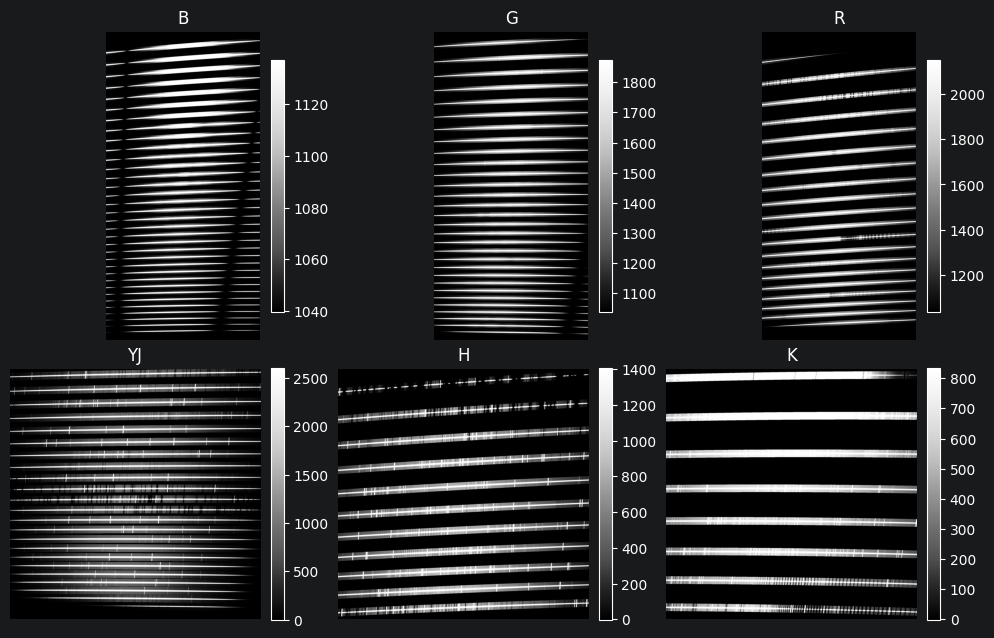

In [15]:
from astropy.visualization import ZScaleInterval

# reduce space between subplots
fig, axes = plt.subplots(2,3, figsize=(12,8), gridspec_kw={'wspace':0.2}, tight_layout=True)
titles = ['B', 'G', 'R', 'YJ', 'H', 'K']
i = 0
for ax, imhdu in zip(axes.flat, hdus):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(imhdu[1].data)
    ax.axis("off")
    im = ax.imshow(imhdu[1].data, origin='lower', vmin=vmin, vmax=vmax, cmap='Grays_r')
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    i += 1

plt.subplots_adjust(wspace=0.0, hspace=0.0)

## Save

In [12]:
import datetime as datetime
from astropy.io import fits

instrument = cmd["!OBS.instrument"]
mode = "_".join(cmd["!OBS.modes"])
scene_name = cmd["!OBS.object"]
filenm_root = f"{instrument}_{mode}-{scene_name}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
file = f"{filenm_root}.fits"


combined_hdus = [fits.PrimaryHDU()]

# Setup addtional PrimaryHDU keys (can also be made into a custom effect of z_order 10xx for header populating)
extension_names = ["B", "G", "R", "YJ", "H", "K"]
for ext_name, channel_hdul in zip(extension_names, hdus):
    image_hdu = channel_hdul[1].copy()
    image_hdu.header["EXTNAME"] = ext_name
    combined_hdus.append(image_hdu)

fits.HDUList(combined_hdus).writeto(file, overwrite=True)
